<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter7_JAX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os

# Sets the environment variable from within the Python runtime
os.environ["KERAS_BACKEND"] = "jax"

import keras

keras.config.backend()

'jax'

In [4]:
# Sequential model

In [5]:
import keras
from keras import layers

model = keras.Sequential(
    [
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)

In [6]:
model = keras.Sequential()
model.add(layers.Dense(64, activation="relu"))
model.add(layers.Dense(10, activation="softmax"))

In [7]:
# At that point, the model isn't built yet.
model.weights

[]

In [8]:
# Builds the model. Now the model will expect samples of shape (3,).
# The None is the input shape signals that the batch size could be anything
model.build(input_shape=(None, 3))

In [9]:
# Now you can retrieve the model's weights.
model.weights

[<Variable path=sequential_1/dense_2/kernel, shape=(3, 64), dtype=float32, value=[[-0.28226313  0.24348423  0.22533716  0.24692968  0.25630522  0.22914211
   -0.05994318  0.14799227  0.2973501  -0.23304503  0.19213185 -0.23681504
    0.24921721 -0.2790615  -0.03296394  0.29588935 -0.15635704  0.244821
    0.00908988 -0.21988565  0.27201164  0.1261927  -0.23820601 -0.2122449
   -0.00966986  0.2891802   0.29694694 -0.27786648  0.11413919  0.03559573
   -0.18707003  0.16589019 -0.04097183  0.02690383 -0.15208232  0.02125133
   -0.03140271  0.0517246   0.01604011 -0.18337767 -0.25735366 -0.03102736
   -0.04710443  0.00051285  0.14470136  0.04776054 -0.10142237 -0.17708054
   -0.09774084  0.08680464  0.13818428 -0.17903396  0.14809914 -0.0874813
   -0.11151018  0.00161017 -0.20570883  0.10081641 -0.02567965  0.20379402
   -0.08935324 -0.02136006  0.18128946  0.21530713]
  [-0.04600975  0.16133095 -0.01006541 -0.24059209 -0.13204497  0.22766516
    0.02705687  0.04032364  0.07770484  0.26467

In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model = keras.Sequential(name="my_example_model")
model.add(layers.Dense(64, activation="relu", name="my_first_layer"))
model.add(layers.Dense(10, activation="softmax", name="my_last_layer"))
model.build((None, 3))
model.summary()

Model: "my_example_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_first_layer (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ my_last_layer (Dense)           │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model = keras.Sequential()

# Use an Input to declare the shape of the inputs. Note that the shape
# argument must be the shaep of each sample, not the shape of one batch.
model.add(keras.Input(shape=(3,)))
model.add(layers.Dense(64, activation="relu"))

In [13]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256 (1.00 KB)

 Trainable params: 256 (1.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.add(layers.Dense(10, activation="softmax"))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
inputs = keras.Input(shape=(3,), name="my_input")
features = layers.Dense(64, activation="relu")(inputs)
outputs = layers.Dense(10, activation="softmax")(features)
model = keras.Model(inputs=inputs, outputs=outputs, name="my_functional_model")

In [16]:
# The model will process bathces where each sample has shape (3,).
# The number of samples per batch is variable (indicated by the # None batch size).
inputs.shape

(None, 3)

In [17]:
# These batches will have dtype float32.
inputs.dtype

'float32'

In [18]:
model.summary()

Model: "my_functional_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_input (InputLayer)           │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 906 (3.54 KB)

 Trainable params: 906 (3.54 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Multi-input, multi-output models
vocabulary_size = 10000
num_tags = 100
num_departments = 4

# Defines model inputs
title = keras.Input(shape=(vocabulary_size,), name="title")
text_body = keras.Input(shape=(vocabulary_size,), name="text_body")
tags = keras.Input(shape=(num_tags,), name="tags")

# Combines input features into a single tensor, features, by concatenating them
features = layers.Concatenate()([title, text_body, tags])

# Applies intermediate layer to recombine input features into recher representations
features = layers.Dense(64, activation="relu", name="dense_features")(features)

# Defines model outputs
priority = layers.Dense(1, activation="sigmoid", name="priority")(features)
department = layers.Dense(
    num_departments, activation="softmax", name="department"
)(features)

# Creates the model by specifying its inputs and outputs
model = keras.Model(
    inputs=[title, text_body, tags],
    outputs=[priority, department],
)

In [20]:
# Training a multi-input, multi-output model
import numpy as np

num_samples = 1280

# Dummy input data
title_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
text_body_data = np.random.randint(0, 2, size=(num_samples, vocabulary_size))
tags_data = np.random.randint(0, 2, size=(num_samples, num_tags))

# Dummy target data
priority_data = np.random.random(size=(num_samples, 1))
department_data = np.random.randint(0, num_departments, size=(num_samples, 1))

model.compile(
    optimizer="adam",
    loss=["mean_squared_error", "sparse_categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)

model.fit(
    [title_data, text_body_data, tags_data],
    [priority_data, department_data],
    epochs=1,
)

model.evaluate(
    [title_data, text_body_data, tags_data], [priority_data, department_data]
)

priority_preds, department_preds = model.predict(
    [title_data, text_body_data, tags_data]
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - department_accuracy: 0.2352 - department_loss: 8.6793 - loss: 9.0229 - priority_loss: 0.3436 - priority_mean_absolute_error: 0.5109
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - department_accuracy: 0.2844 - department_loss: 8.4818 - loss: 8.8298 - priority_loss: 0.3481 - priority_mean_absolute_error: 0.5152
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [21]:
# Use the names you gave to the Input objects and to the output layers, and pass data via dictionaries
model.compile(
    optimizer="adam",
    loss={
        "priority": "mean_squared_error",
        "department": "sparse_categorical_crossentropy",
    },
    metrics={
        "priority": ["mean_absolute_error"],
        "department": ["accuracy"],
    },
)

model.fit(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
    epochs=1,
)

model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    {"priority": priority_data, "department": department_data},
)

priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - department_accuracy: 0.2641 - department_loss: 9.2006 - loss: 9.5487 - priority_loss: 0.3481 - priority_mean_absolute_error: 0.5152
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - department_accuracy: 0.2898 - department_loss: 8.4872 - loss: 8.8352 - priority_loss: 0.3481 - priority_mean_absolute_error: 0.5152
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


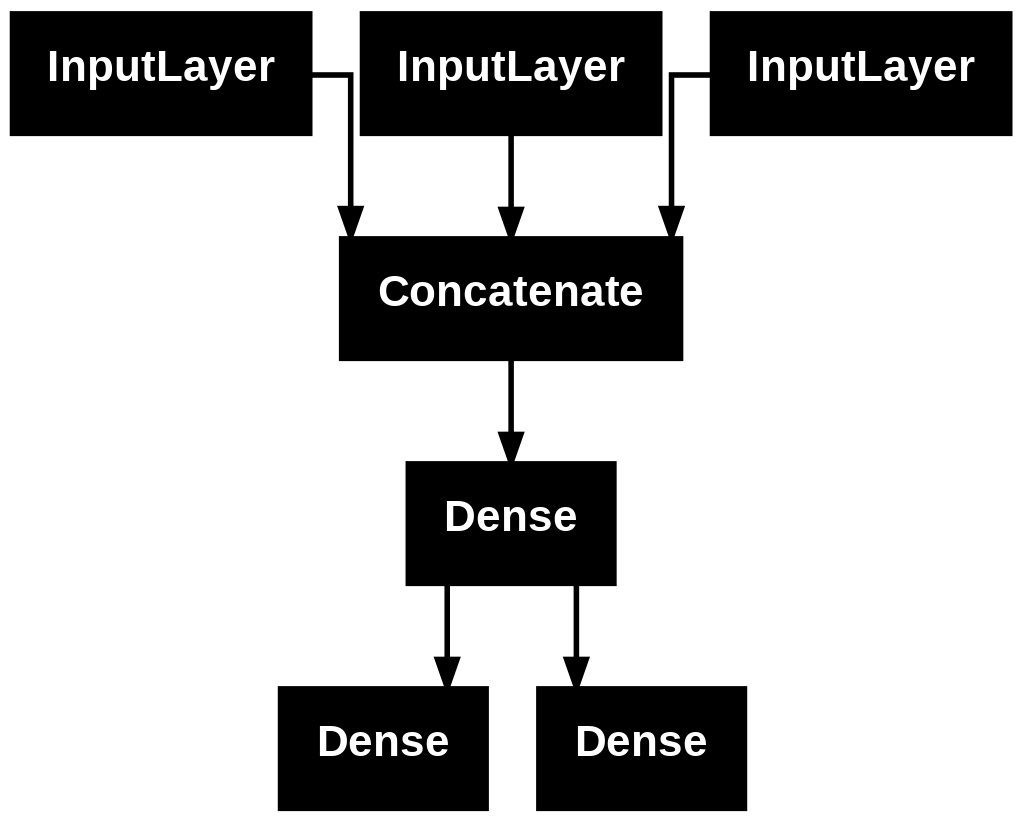

In [22]:
keras.utils.plot_model(model, "ticket_classifier.png")

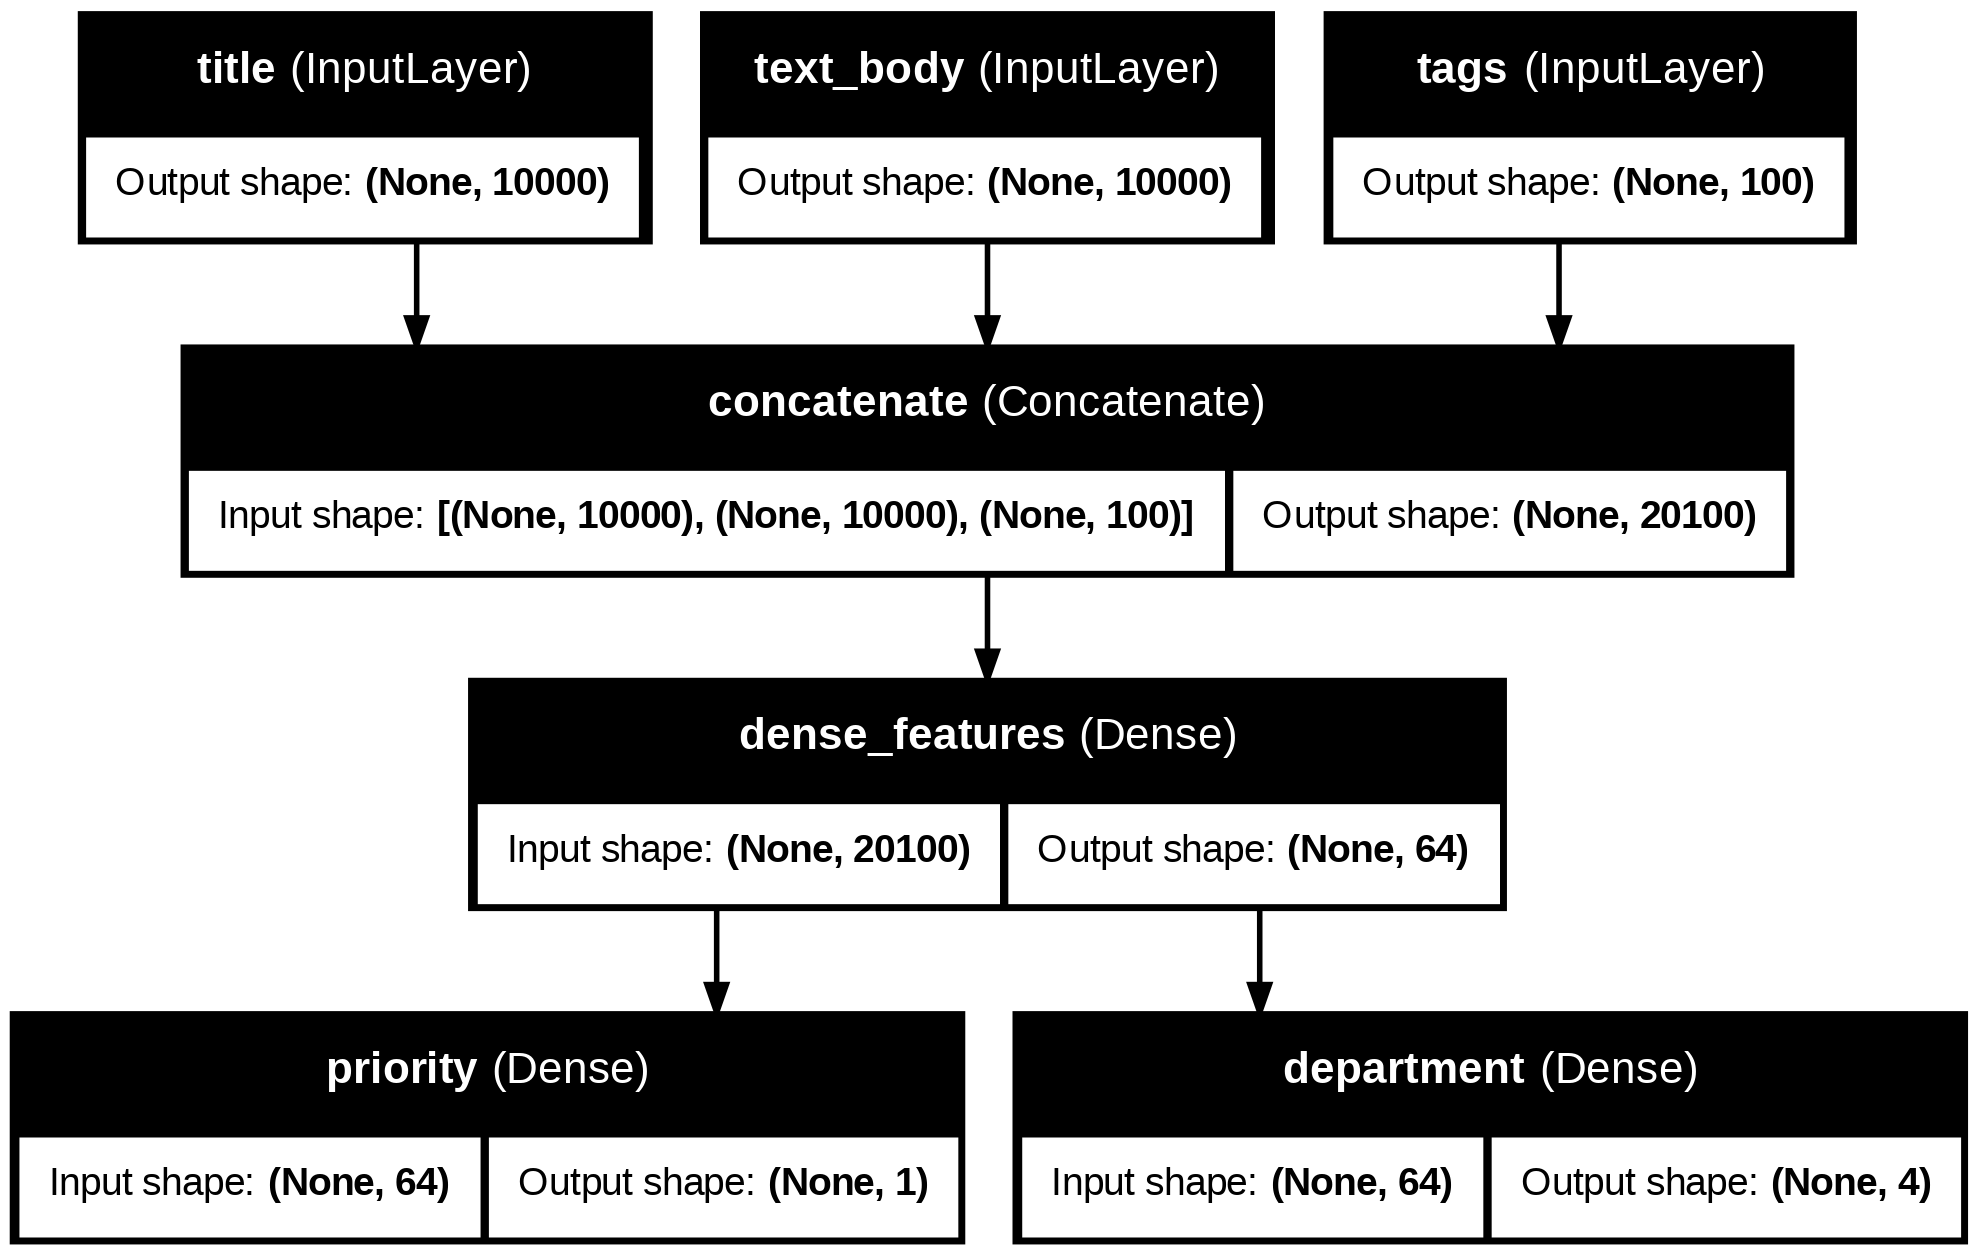

In [23]:
keras.utils.plot_model(
    model,
    "ticket_classifier_with_shape_info.png",
    show_shapes=True,
    show_layer_names=True,
)

In [24]:
model.layers

[<InputLayer name=title, built=True>,
 <InputLayer name=text_body, built=True>,
 <InputLayer name=tags, built=True>,
 <Concatenate name=concatenate, built=True>,
 <Dense name=dense_features, built=True>,
 <Dense name=priority, built=True>,
 <Dense name=department, built=True>]

In [25]:
model.layers[3].input

[<KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=title>,
 <KerasTensor shape=(None, 10000), dtype=float32, sparse=False, ragged=False, name=text_body>,
 <KerasTensor shape=(None, 100), dtype=float32, sparse=False, ragged=False, name=tags>]

In [26]:
model.layers[3].output

<KerasTensor shape=(None, 20100), dtype=float32, sparse=False, ragged=False, name=keras_tensor_12>

In [27]:
# layers[4] is our intermediate Dense layer.
features = model.layers[4].output
difficulty = layers.Dense(3, activation="softmax", name="difficulty")(features)

new_model = keras.Model(
    inputs=[title, text_body, tags], outputs=[priority, department, difficulty]
)

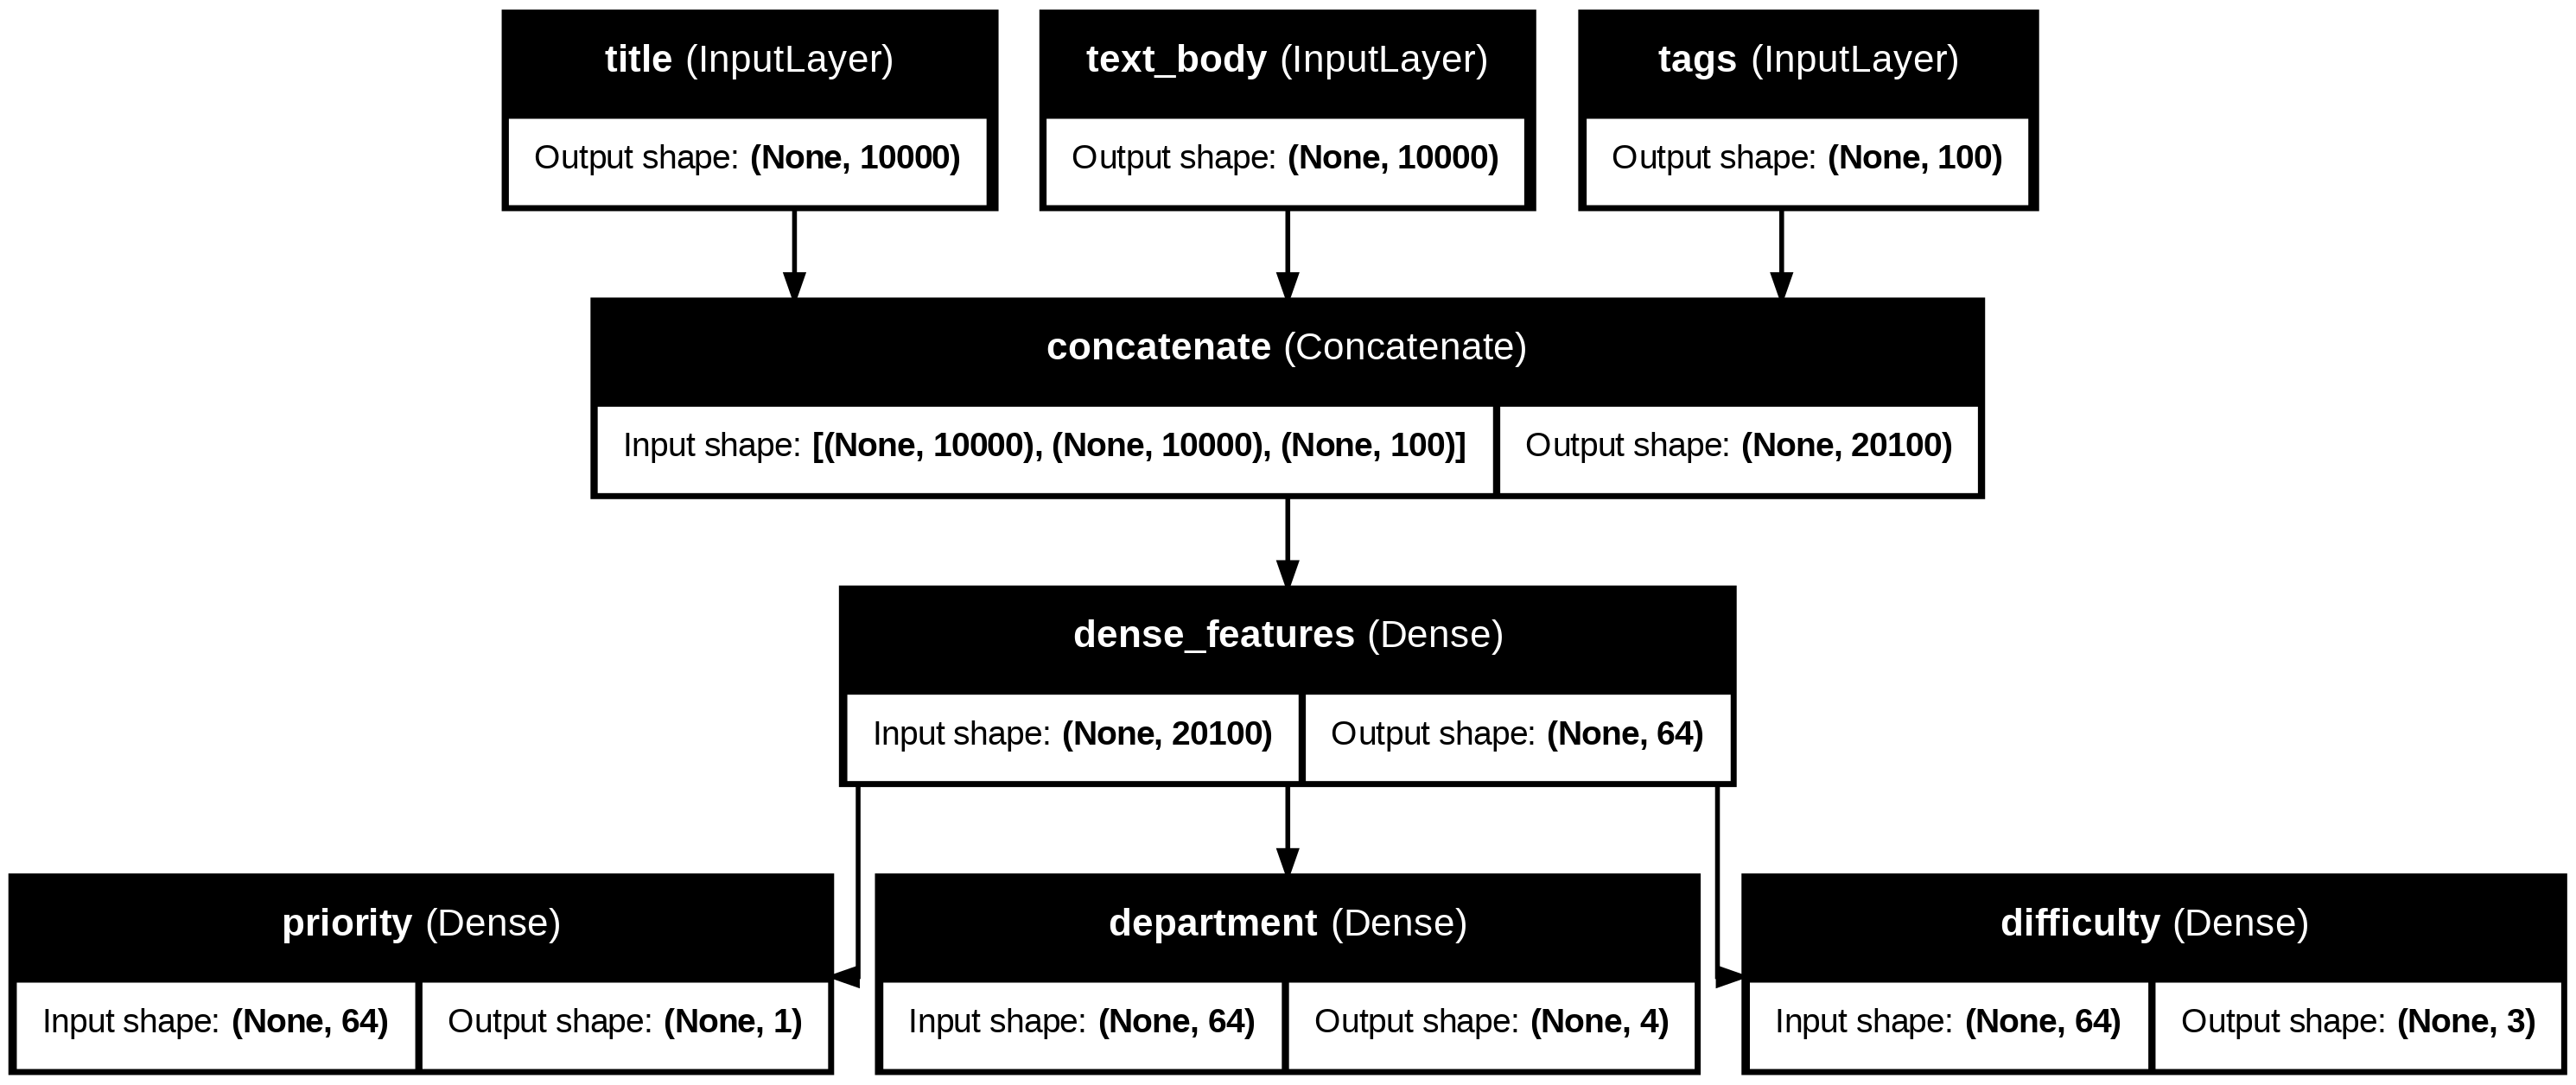

In [28]:
keras.utils.plot_model(
    new_model,
    "updated_ticket_classifier.png",
    show_shapes=True,
    show_layer_names=True,
)

In [29]:
# Rewriting our previous example as a subclass model
class CustomerTicketModel(keras.Model):
    def __init__(self, num_departments):
        # Don't forget to call the super constructor!
        super().__init__()

        # Defines sublayers in the constructor
        self.concat_layer = layers.Concatenate()
        self.mixing_layer = layers.Dense(64, activation="relu")
        self.priority_scorer = layers.Dense(1, activation="sigmoid")
        self.department_classifier = layers.Dense(
            num_departments, activation="softmax"
        )


    # Defines the forward pass in the call() method
    def call(self, inputs):
        title = inputs["title"]
        text_body = inputs["text_body"]
        tags = inputs["tags"]

        features = self.concat_layer([title, text_body, tags])
        features = self.mixing_layer(features)
        priority = self.priority_scorer(features)
        department = self.department_classifier(features)

        return priority, department

In [30]:
model = CustomerTicketModel(num_departments=4)

priority, department = model(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

In [31]:
model.compile(
    optimizer="adam",

    # The structure of what you pass as the loss and metrics must match
    # exactly what gets returned by call() - since we returned a list
    # of two elements, so should loss and metrics be lists of two elements.
    loss=["mean_squared_error", "sparse_categorical_crossentropy"],
    metrics=[["mean_absolute_error"], ["accuracy"]],
)

model.fit(
    # The stucture of the input data must match exaclty what is
    # expected by the call() method, and the structure of the target
    # data must match exactly what gets returned by the call() method.
    # Here, the input data must be a dict with three keys (title,
    # text_body, and tags) and the target data must be a list of two elements.
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
    epochs=1,
)

model.evaluate(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data},
    [priority_data, department_data],
)

priority_preds, department_preds = model.predict(
    {"title": title_data, "text_body": text_body_data, "tags": tags_data}
)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.2539 - loss: 12.0459 - mean_absolute_error: 0.4811 - mean_squared_error_loss: 0.3135 - sparse_categorical_crossentropy_loss: 11.7324
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2562 - loss: 12.3054 - mean_absolute_error: 0.4848 - mean_squared_error_loss: 0.3176 - sparse_categorical_crossentropy_loss: 11.9878
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [32]:
# Mixing and matching different components
# We can use a subclassed layer or model in a Functional model
class Classifier(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        if num_classes == 2:
            num_units = 1
            activation = "sgmoid"

        else:
            num_units = num_classes
            activation = "softmax"

        self.dense = layers.Dense(num_units, activation=activation)


    def call(self, inputs):
        return self.dense(inputs)


inputs = keras.Input(shape=(3,))
features = layers.Dense(64, activation="relu")(inputs)
outputs = Classifier(num_classes=10)(features)
model = keras.Model(inputs=inputs, outputs=outputs)

In [33]:
# Inversely, you can use a functional model as part of a subclassed layer or model
inputs = keras.Input(shape=(64,))
outputs = layers.Dense(1, activation="sigmoid")(inputs)
binary_classifier = keras.Model(inputs=inputs, outputs=outputs)

class MyModel(keras.Model):
    def __init__(self, num_classes=2):
        super().__init__()
        self.dense = layers.Dense(64, activation="relu")
        self.classifiler = binary_classifier


    def call(self, inputs):
        features = self.dense(inputs)

        return self.classifier(features)

model = MyModel()

In [34]:
# Using built-in training and evaluation loops

In [35]:
from keras.datasets import mnist

# Create a model
def get_mnist_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = keras.Model(inputs, outputs)

    return model

# Loads your data, reserving some for validation
(images, labels), (test_images, test_labels) = mnist.load_data()
images = images.reshape((60000, 28 * 28)).astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255

train_images, val_images = images[10000:], images[:10000]
train_labels, val_labels = labels[10000:], labels[:10000]

model = get_mnist_model()

# Compiles the model by specifying its optimizer, the loss function to
# minimize, and metrics to monitor
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Uses `fit()` to train the model, optionally providing validation data
# to monitor performance on unseen data
model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)

# Uses `evaluate()` to compute the loss and metrics on new data
test_metrics = model.evaluate(test_images, test_labels)

# Uses `predict()` to compute classification probabilities on new data
predictions = model.predict(test_images)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9142 - loss: 0.2865 - val_accuracy: 0.9571 - val_loss: 0.1377
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9557 - loss: 0.1450 - val_accuracy: 0.9698 - val_loss: 0.1015
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9644 - loss: 0.1146 - val_accuracy: 0.9738 - val_loss: 0.0904
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9716 - loss: 0.0895
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [36]:
from keras import ops

# Subclasses the Metric class
class RootMeanSquaredError(keras.metrics.Metric):
    # Defines the state variables in the constructor.
    # Like for layers, you have access to the add_weight() method.
    def __init__(self, name="rmse", **kwargs):
        super().__init__(name=name, **kwargs)
        self.mse_sum = self.add_weight(name="mse_sum", initializer="zeros")
        self.total_samples = self.add_weight(
            name="total_samples", initializer="zeros"
        )


    # Implements the state update logic in update_sate().
    # The y_true argument is the targest (or labels) for one batch, while y_red represents
    # the corresponding predictions form the model.
    # To match our MNIST model, we expect categorical predictions and integer labels.
    # You can ignore the sample_weight argument; we won't use it here
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true = ops.one_hot(y_true, num_classes=ops.shape(y_pred)[1])
        mse = ops.sum(ops.square(y_true - y_pred))
        self.mse_sum.assign_add(mse)
        num_samples = ops.shape(y_pred)[0]
        self.total_samples.assign_add(num_samples)


    def result(self):
        return ops.sqrt(self.mse_sum / self.total_samples)


    def reset_state(self):
        self.mse_sum.assign(0.)
        self.total_samples.assign(0.)

In [37]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", RootMeanSquaredError()],
)

model.fit(
    train_images,
    train_labels,
    epochs=3,
    validation_data=(val_images, val_labels),
)

test_metrics = model.evaluate(test_images, test_labels)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9129 - loss: 0.2894 - rmse: 0.3622 - val_accuracy: 0.9554 - val_loss: 0.1456 - val_rmse: 0.2570
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9554 - loss: 0.1470 - rmse: 0.2612 - val_accuracy: 0.9722 - val_loss: 0.0969 - val_rmse: 0.2089
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9644 - loss: 0.1157 - rmse: 0.2341 - val_accuracy: 0.9737 - val_loss: 0.0856 - val_rmse: 0.1992
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9735 - loss: 0.0836 - rmse: 0.1997


In [38]:
# Callbacks are passed to the model via the callbacks argument in fit(),
# which takes a list of callbacks. You can pass any number of callbacks.
callbacks_list = [
    # Interrrupts training when improvement stops
    keras.callbacks.EarlyStopping(
        # Monitors the model's validation accuracy
        monitor="accuracy",

        # Interrupts training when accuracy has stopped imporiving for
        # more than one epoch (that is, two epochs)
        patience=1,
    ),

    # Saves the current weights after every epoch
    keras.callbacks.ModelCheckpoint(
        # Path to the destination model file
        filepath="checkpoint_path.keras",

        # These two arguments mean you won't overwrite the model file unless
        # val_loss has improved, which allows you to keep the best model sen during training.
        monitor="val_loss",
        save_best_only=True
    ),
]

model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# Because the callback will monitor validation loss and validation accuracy,
# you need to pass validation_data to the call to fit().
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=callbacks_list,
    validation_data=(val_images, val_labels),
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9131 - loss: 0.2907 - val_accuracy: 0.9617 - val_loss: 0.1317
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9549 - loss: 0.1489 - val_accuracy: 0.9677 - val_loss: 0.1115
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9646 - loss: 0.1129 - val_accuracy: 0.9733 - val_loss: 0.0913
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9692 - loss: 0.0968 - val_accuracy: 0.9726 - val_loss: 0.0900
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9738 - loss: 0.0829 - val_accuracy: 0.9777 - val_loss: 0.0743
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9763 - loss: 0.0749 - val_accuracy: 0.9789 - val_loss: 0.0747
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9779 - loss: 0.0712 - val_accuracy: 0.9790 - val_loss: 0.0753
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9801 - loss: 0.0629 -

In [39]:
# Reload the model you've saved
model = keras.models.load_model("checkpoint_path.keras")

In [40]:
# Creating a custom callback by subclassing the Callback class
from matplotlib import pyplot as plt

class LossHistory(keras.callbacks.Callback):
    def on_train_begin(self, logs):
        self.per_batch_losses = []


    def on_batch_end(self, bathc, logs):
        self.per_batch_losses.append(logs.get("loss"))


    def on_epoch_end(self, epoch, logs):
        plt.clf()

        plt.plot(
            range(len(self.per_batch_losses)),
            self.per_batch_losses,
            label="Training loss for each batch",
        )

        plt.xlabel(f"Batch (epoch {epoch})")
        plt.ylabel("Loss")
        plt.legend()
        plt.savefig(f"plot_at_epoch_{epoch}", dpi=300)

        self.per_batch_losses = []


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9138 - loss: 0.2874 - val_accuracy: 0.9566 - val_loss: 0.1421
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9551 - loss: 0.1471 - val_accuracy: 0.9684 - val_loss: 0.1036
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9650 - loss: 0.1121 - val_accuracy: 0.9717 - val_loss: 0.0930
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9701 - loss: 0.0961 - val_accuracy: 0.9755 - val_loss: 0.0811
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9736 - loss: 0.0835 - val_accuracy: 0.9753 - val_loss: 0.0832
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9751 - loss: 0.0763 - val_accuracy: 0.9770 - val_loss: 0.0769
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9786 - loss: 0.0679 - val_accuracy: 0.9789 - val_loss: 0.0736
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9792 - loss: 0.0650 -

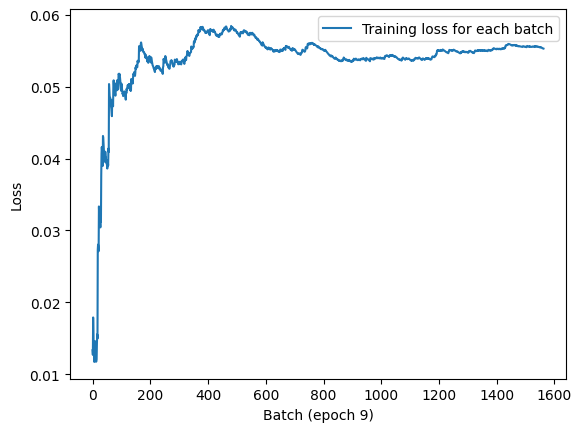

In [41]:
model = get_mnist_model()
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    train_labels,
    epochs=10,
    callbacks=[LossHistory()],
    validation_data=(val_images, val_labels),
)

In [42]:
# Writing custom training step functions

In [47]:
import keras
from keras import layers
import jax

loss_fn = keras.losses.SparseCategoricalCrossentropy()

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = loss_fn(targets, predictions)
        # Returns both the loss and the updated non-trainable variables
        return loss, non_trainable_variables


    def train_step(self, state, data):
        # Unpacks the state. metrics_variables are part of it, although
        # we won't use them here.
        (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        ) = state
        inputs, targets = data

        # Gets the gradient function
        grad_fn = jax.value_and_grad(
            self.compute_loss_and_updates, has_aux=True
        )

        # Computes gradients and updates to non-trainable variables
        (loss, non_trainable_variables), grads = grad_fn(
            trainable_variables,
            non_trainable_variables,
            inputs,
            targets,
            training=True,
        )

        # Updates trainable variables and optimizer variables
        (
            trainable_variables,
            optimizer_variables,
        ) = self.optimizer.stateless_apply(
            optimizer_variables, grads, trainable_variables
        )

        # We aren't computing a moving average of the loss, instead
        # returning the per-batch value.
        logs = {"loss": loss}
        state = (
            trainable_variables,
            non_trainable_variables,
            optimizer_variables,
            metrics_variables,
        )
        # Returns metric logs and updated state variables
        return logs, state

In [48]:
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam())

    return model

In [49]:
model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0000e+00
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0000e+00
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0000e+00


In [50]:
import keras
from keras import layers

class CustomModel(keras.Model):
    def compute_loss_and_updates(
        self,
        trainable_variables,
        non_trainable_variables,
        inputs,
        targets,
        training=False,
    ):
        predictions, non_trainable_variables = self.stateless_call(
            trainable_variables,
            non_trainable_variables,
            inputs,
            training=training,
        )
        loss = self.compute_loss(y=targets, y_pred=predictions)
        return loss, (predictions, non_trainable_variables)


    def train_step(self, state, data):
            (
                trainable_variables,
                non_trainable_variables,
                optimizer_variables,
                # Metric variables are part of the state.
                metrics_variables,
            ) = state
            inputs, targets = data

            grad_fn = jax.value_and_grad(
                self.compute_loss_and_updates, has_aux=True
            )

            (loss, (predictions, non_trainable_variables)), grads = grad_fn(
                trainable_variables,
                non_trainable_variables,
                inputs,
                targets,
                training=True,
            )
            (
                trainable_variables,
                optimizer_variables,
            ) = self.optimizer.stateless_apply(
                optimizer_variables, grads, trainable_variables
            )

            new_metrics_vars = []
            logs = {}
            # Iterates over metrics
            for metric in self.metrics:
                num_prev = len(new_metrics_vars)
                num_current = len(metric.variables)
                # Grabs the variables of the current metrics
                current_vars = metrics_variables[num_prev : num_prev + num_current]
                # Updates the metric's state
                if metric.name == "loss":
                    current_vars = metric.stateless_update_state(current_vars, loss)
                else:
                    current_vars = metric.stateless_update_state(
                        current_vars, targets, predictions
                    )
                # Stores the results in the logs dict
                logs[metric.name] = metric.stateless_result(current_vars)
                new_metrics_vars += current_vars

            state = (
                trainable_variables,
                non_trainable_variables,
                optimizer_variables,
                # Returns the new metrics variables as part of the state
                new_metrics_vars,
            )
            return logs, state

In [51]:
def get_custom_model():
    inputs = keras.Input(shape=(28 * 28,))
    features = layers.Dense(512, activation="relu")(inputs)
    features = layers.Dropout(0.5)(features)
    outputs = layers.Dense(10, activation="softmax")(features)
    model = CustomModel(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.SparseCategoricalAccuracy()],
    )
    return model

model = get_custom_model()
model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - sparse_categorical_accuracy: 0.9121 - loss: 0.2929
Epoch 2/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - sparse_categorical_accuracy: 0.9565 - loss: 0.1461
Epoch 3/3
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - sparse_categorical_accuracy: 0.9659 - loss: 0.1103
